# Reading in data: Youth Tobacco Survey

Peter Ralph  
2026-01-05

# Reading in data

Peter Ralph

https://uodsci.github.io/ds435

Set-up:

In [ ]:
import pandas as pd

# The National Youth Tobacco Survey

The
[NYTS](https://www.cdc.gov/tobacco/about-data/surveys/national-youth-tobacco-survey.html)
is a CDC-funded national survey running since 1999 to assess youth rates
of tobacco usage.

Datasets, by year, are currently available on [this
page](https://www.cdc.gov/tobacco/about-data/surveys/historical-nyts-data-and-documentation.html).

We’re going to look at the 1999 version. Go **read the documentation**.

## Download

We’ve got the option to download an MS Access or SAS file. We’ll use the
SAS version. Get the files:

    mkdir -p data
    wget -P data https://www.cdc.gov/tobacco/data_statistics/surveys/nyts/zip_files/1999_Codebook_Dataset_SAS.zip
    unzip -d data data/1999_Codebook_Dataset_SAS.zip

and then read the PDF. **(5-minute reading interlude)**

In [ ]:
orig_yts = pd.read_sas("data/nyts1999public.sas7bdat").convert_dtypes()
orig_yts

## Summaries

The data should all be from 1999? Oh, good:

In [ ]:
orig_yts.YEAR.value_counts(dropna=True)

## 

Are the `STUDNTID` numbers all unique? Oh, good.

In [ ]:
orig_yts.STUDNTID.value_counts().max()

## 

What is `WT`? It’s not weight-in-pounds:

In [ ]:
orig_yts.WT.describe()

## 

Other questions?

## Question 1

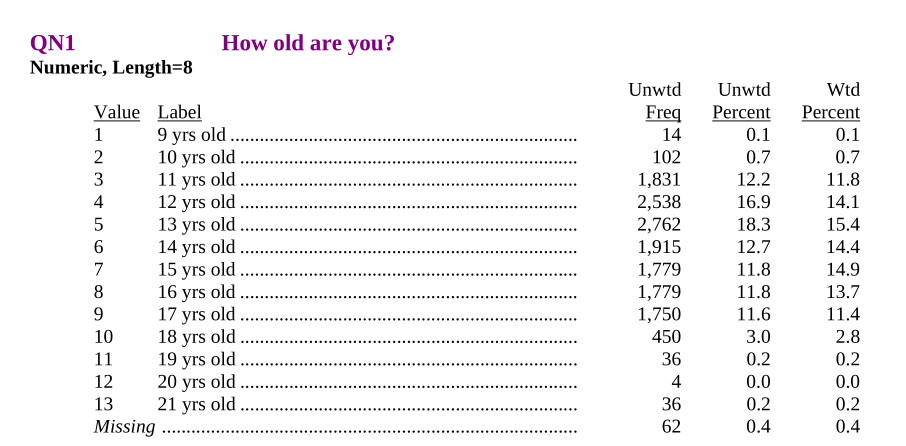

In [ ]:
orig_yts.QN1.value_counts(dropna=False)

## Let’s recode this

We’ll store all the new variables in a dictionary and make that into a
`DataFrame` at the end (in that order, because pandas).

In [ ]:
yts = {}
yts['age'] = orig_yts.QN1 + 8
yts['age'].value_counts(dropna=False)

## Question 3

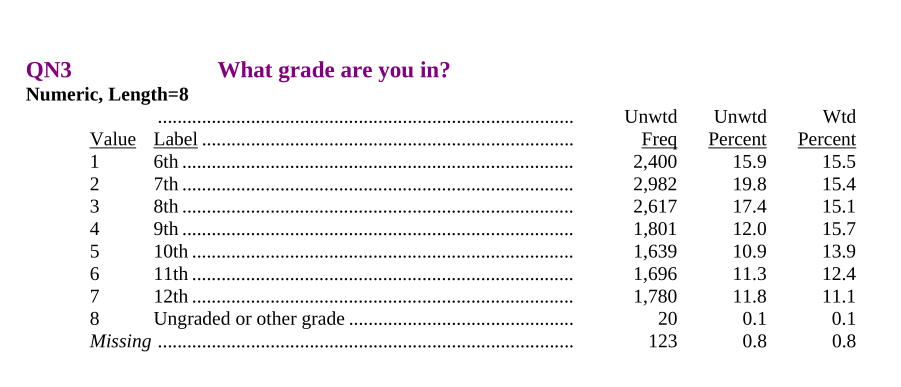

In [ ]:
yts['grade'] = orig_yts.QN3 + 5
yts['grade'].value_counts(dropna=False)

## Consistency checking

In [ ]:
pd.crosstab(yts['grade'], yts['age'])

## Question 2

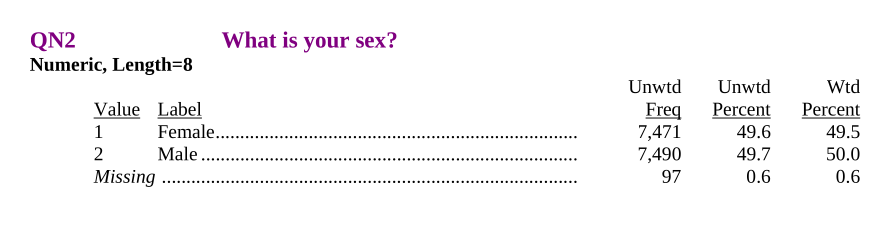  

“*Missing*” can be a useful option for survey questions.

In [ ]:
orig_yts.QN2.value_counts(dropna=False)

In [ ]:
import collections
d = collections.defaultdict(lambda: None, 
    { 1 : "F", 2 : "M" }
)
yts['sex'] = pd.Series([d[k] for k in orig_yts.QN2], dtype='string')
yts['sex'].value_counts(dropna=False)

## Question 6

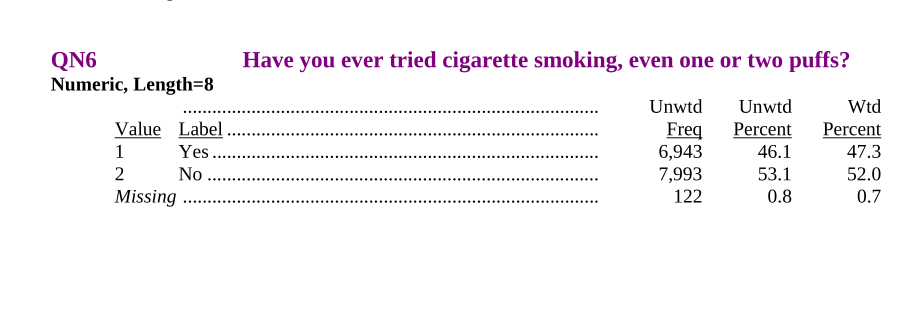

In [ ]:
d = collections.defaultdict(lambda: None, 
    { 1 : True, 2 : False }
)
yts['ever_smoked'] = pd.Series([d[k] for k in orig_yts.QN6], dtype='boolean')
yts['ever_smoked'].value_counts(dropna=False)

# Put it together

In [ ]:
yts = pd.DataFrame(yts)
yts

## Summarize

We want to
[split-apply-combine](https://pandas.pydata.org/docs/user_guide/groupby.html#aggregation).
See [this
list](https://pandas.pydata.org/docs/user_guide/groupby.html#built-in-aggregation-methods)
of built-in aggregation methods.

In [ ]:
yts.groupby(["grade","sex"]).aggregate(
    prop_smoked = ("ever_smoked", "mean"),
    n = ("ever_smoked", "size")
)

## Missing Values

What about the missing values?

**Question:** what does `pandas` say the “mean” of `[True, False, NA]`
is? (What should it say?)

In [ ]:
pd.Series([True, False, pd.NA], dtype="boolean").mean()

# Discussion

## What are questions you might ask using these data?

## How “good” do these data seem for answering those questions?